In [1]:
from sklearn.datasets import fetch_lfw_people, get_data_home

faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.images.shape)
print(get_data_home())

(1348, 62, 47)
C:\Users\q_wr2\scikit_learn_data


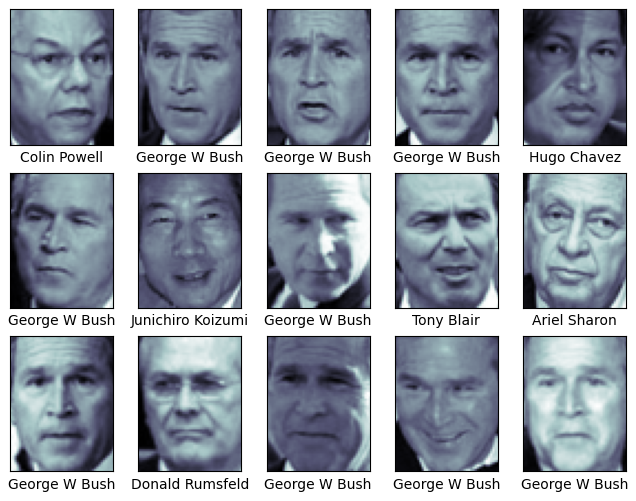

In [3]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(3,5,figsize=(8,6))
for i,axi in enumerate(ax.flat):
    axi.imshow(faces.images[i],cmap='bone')
    axi.set(xticks=[],yticks=[],xlabel=faces.target_names[faces.target[i]])

In [4]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

In [5]:
pca = PCA(n_components=150,whiten=True,svd_solver='randomized',random_state=42)
svc = SVC(kernel='rbf',class_weight='balanced')
model = make_pipeline(pca,svc)
from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest = train_test_split(faces.data,faces.target,random_state=42)

In [6]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C':[1,5,10,50],
              'svc__gamma':[0.0001,0.0005,0.001,0.005]}
grid = GridSearchCV(model,param_grid)
%time grid.fit(Xtrain,ytrain)
print(grid.best_params_)

CPU times: total: 1min 32s
Wall time: 31.6 s
{'svc__C': 5, 'svc__gamma': 0.001}


In [7]:
model = grid.best_estimator_
yfit = model.predict(Xtest)

In [8]:
from sklearn.metrics import classification_report
print(classification_report(ytest,yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



Text(113.92222222222219, 0.5, 'predicted label')

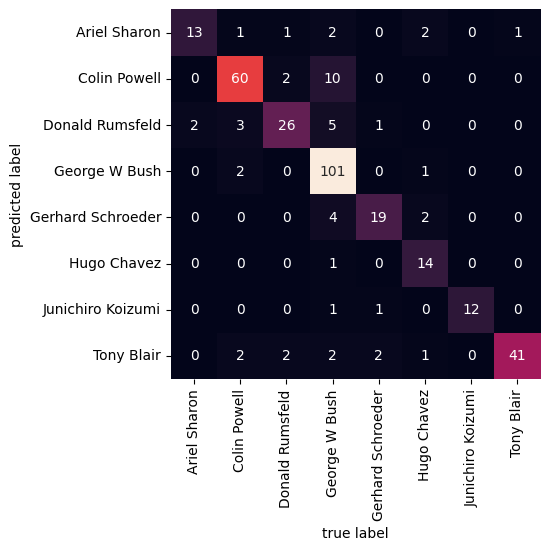

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
mat = confusion_matrix(ytest,yfit)
sns.heatmap(mat.T,square=True,annot=True,fmt='d',cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')